# 04 — Modelo de Clasificación: Predicción de Riesgo de Retraso

**Tarea:** predecir `es_retraso` (0 = a tiempo, 1 = retraso)  
**Arquitectura:** igual que el modelo de regresión, solo cambia la capa de salida  
**Loss:** BinaryCrossentropy · **Manejo de desbalance:** class_weight

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)

DATA_DIR   = Path('../data/processed')
MODELS_DIR = Path('../models')
OUT_DIR    = Path('../outputs/graficas')

TensorFlow: 2.21.0


## 1. Cargar datos procesados

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
val   = pd.read_csv(DATA_DIR / 'val.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'preprocesadores.pkl', 'rb') as f:
    prep = pickle.load(f)

FEATURES_NUM = prep['features_num']
FEATURES_CAT = prep['features_cat']
CARDS        = prep['cardinalidades']

print(f'Tasa retraso en train: {train["es_retraso"].mean():.1%}')

Tasa retraso en train: 8.5%


## 2. Preparar inputs y calcular class_weight

In [3]:
def preparar_inputs(df):
    X_num = df[FEATURES_NUM].values.astype('float32')
    X_cat = [df[col].values.astype('int32') for col in FEATURES_CAT]
    return [X_num] + X_cat

X_train = preparar_inputs(train)
y_train = train['es_retraso'].values.astype('float32')

X_val   = preparar_inputs(val)
y_val   = val['es_retraso'].values.astype('float32')

X_test  = preparar_inputs(test)
y_test  = test['es_retraso'].values.astype('float32')

# Calcular pesos de clase para compensar el desbalance
pesos_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight = {0: pesos_array[0], 1: pesos_array[1]}
print(f'Class weights: {class_weight}')

Class weights: {0: np.float64(0.5463834803232358), 1: np.float64(5.8898499693815065)}


## 3. Arquitectura de la red

In [4]:
def construir_modelo_clasificacion(cards, n_num):
    """
    Misma arquitectura base que regresión.
    Salida: sigmoid → probabilidad de retraso.
    """
    # Entrada numérica
    inp_num = keras.Input(shape=(n_num,), name='input_numerico')

    # Embeddigns categóricos
    emb_outputs = []
    emb_inputs  = []
    for col, card in cards.items():
        dim = min(50, (card // 2) + 1)
        inp = keras.Input(shape=(1,), name=f'input_{col}', dtype='int32')
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        emb_inputs.append(inp)
        emb_outputs.append(emb)

    # Concatenar
    x = layers.Concatenate()([inp_num] + emb_outputs)

    # Bloques densos
    for unidades in [256, 128, 64]:
        x = layers.Dense(unidades, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3 if unidades == 256 else 0.2)(x)

    # Salida clasificación binaria
    salida = layers.Dense(1, activation='sigmoid', name='es_retraso')(x)

    modelo = keras.Model(
        inputs=[inp_num] + emb_inputs,
        outputs=salida,
        name='modelo_clasificacion'
    )
    return modelo

modelo = construir_modelo_clasificacion(CARDS, n_num=len(FEATURES_NUM))
modelo.summary()

Model: "modelo_clasificacion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_categoria_pr… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_customer_sta… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_seller_state  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_categoria_prod… │ (None, 1, 37)     │      2,664 │ input_categoria_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_customer_state  │ (None, 1, 14)     │        378 │ input_customer_s… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_seller_state    │ (None, 1, 12)     │        264 │ input_seller_sta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerico      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 37)        │          0 │ emb_categoria_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 14)        │          0 │ emb_customer_sta… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12)        │          0 │ emb_seller_state… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 71)        │          0 │ input_numerico[0… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     18,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]   

 Total params: 64,747 (252.92 KB)

 Trainable params: 63,851 (249.42 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Compilar y entrenar

In [5]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        restore_best_weights=True,
        mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, verbose=1
    )
]

historia = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5669 - auc: 0.5916 - loss: 0.7343 - val_accuracy: 0.8760 - val_auc: 0.6312 - val_loss: 0.5058 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6065 - auc: 0.6453 - loss: 0.6731 - val_accuracy: 0.8382 - val_auc: 0.6423 - val_loss: 0.4724 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6425 - auc: 0.6786 - loss: 0.6479 - val_accuracy: 0.8722 - val_auc: 0.6771 - val_loss: 0.4221 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6522 - auc: 0.6921 - loss: 0.6377 - val_accuracy: 0.8924 - val_auc: 0.6835 - val_loss: 0.3944 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6639 - auc: 0.7039 - loss: 0.6281 - val_accuracy: 0.8828 - val_auc: 0.6630 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6681 - a

## 5. Curva de aprendizaje

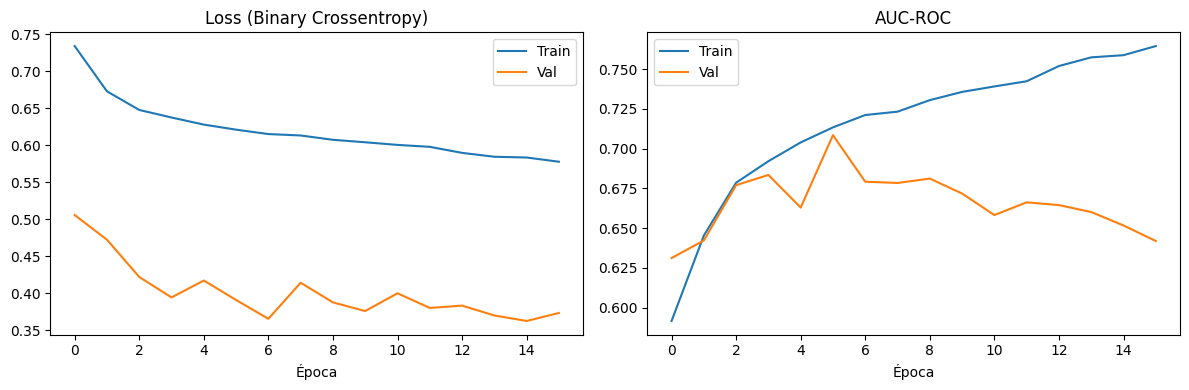

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia.history['loss'],     label='Train')
axes[0].plot(historia.history['val_loss'], label='Val')
axes[0].set_title('Loss (Binary Crossentropy)')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(historia.history['auc'],     label='Train')
axes[1].plot(historia.history['val_auc'], label='Val')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'curva_clasificacion.png', dpi=100)
plt.show()

## 6. Métricas en test

In [7]:
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

y_prob = modelo.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['A tiempo', 'Retraso']))

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AUC-ROC: 0.5565
F1-Score: 0.0326

              precision    recall  f1-score   support

    A tiempo       0.91      0.93      0.92      8797
     Retraso       0.04      0.03      0.03       822

    accuracy                           0.85      9619
   macro avg       0.47      0.48      0.48      9619
weighted avg       0.84      0.85      0.84      9619



## 7. Guardar modelo

In [8]:
modelo.save(MODELS_DIR / 'modelo_clasificacion.keras')
print('Modelo guardado en models/modelo_clasificacion.keras')

Modelo guardado en models/modelo_clasificacion.keras
